#### SAM2 포인트 세그멘테이션 (Hugging Face 직접 사용)

`transformers`의 `Sam2Processor` / `Sam2Model`만으로 추론합니다. **포인트 선택**은 원본 노트북과 같이 **PyQt5** 창에서 마우스로 찍습니다 (`pick_pos_neg_points_qt` — `qt_widgets.py`와 동일 로직을 노트북에 인라인 복사).

**입력:** 로컬 **RGB 이미지 파일 경로**, 전경은 **좌클릭·배경은 우클릭**으로 찍은 **픽셀 좌표 (x,y) 목록**(Qt 픽커 또는 대안 셀의 수동 좌표), Hugging Face **`MODEL_ID`**(예: `facebook/sam2.1-hiera-base-plus`).

**출력:** 원본과 같은 해상도의 **이진 세그멘테이션 마스크**(`bool` 배열; 후보 마스크 중 선택·구멍 채우기·최대 연결요소 등 후처리), `matplotlib`로 **원본·마스크·오버레이·클릭 위치** 시각화.

**의존성:** `torch`, `transformers`, `pillow`, `numpy`, `matplotlib`, `scipy`, **`PyQt5`**

```bash
pip install torch transformers pillow numpy matplotlib scipy accelerate PyQt5
```

**디바이스:** `SAM2_DEVICE`(`cuda`/`mps`/`cpu`)가 있으면 우선 사용, 없으면 CUDA → MPS → CPU.

**Qt 픽커:** 데스크톱에서 Jupyter/스크립트 실행 시 창이 떠야 합니다. 원격·헤드리스 환경이면 아래 대안 셀에서 좌표를 직접 지정하세요.


In [1]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image
from scipy.ndimage import binary_fill_holes, label
from transformers import Sam2Processor, Sam2Model

In [2]:
def pick_torch_device(verbose: bool = True) -> torch.device:
    """CUDA > MPS > CPU. SAM2_DEVICE 환경 변수로 강제 가능."""
    forced = os.environ.get("SAM2_DEVICE", "").strip().lower()
    if forced in ("cuda", "mps", "cpu"):
        if forced == "cuda" and not torch.cuda.is_available():
            raise RuntimeError("SAM2_DEVICE=cuda 이지만 CUDA를 쓸 수 없습니다.")
        if forced == "mps":
            if not (hasattr(torch.backends, "mps") and torch.backends.mps.is_available()):
                raise RuntimeError("SAM2_DEVICE=mps 이지만 MPS를 쓸 수 없습니다.")
        if verbose:
            print(f"[device] 환경 변수 SAM2_DEVICE=[{forced}]")
        return torch.device(forced)
    if torch.cuda.is_available():
        if verbose:
            print("[device] CUDA")
        return torch.device("cuda")
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        if verbose:
            print("[device] MPS (Apple Silicon)")
        return torch.device("mps")
    if verbose:
        print("[device] CPU")
    return torch.device("cpu")


def to_int_xy(p):
    try:
        return [int(round(float(p[0]))), int(round(float(p[1])))]
    except Exception:
        return None


def norm_points_xy_list(xy_list):
    if xy_list is None:
        return []
    out = []
    for p in xy_list:
        q = to_int_xy(p)
        if q is not None:
            out.append(q)
    return out


def keep_largest_cc(mask: np.ndarray) -> np.ndarray:
    mask = np.asarray(mask).astype(bool)
    structure = np.ones((3, 3), dtype=np.int8)
    lab, n = label(mask, structure=structure)
    if int(n) == 0:
        return mask
    sizes = np.bincount(lab.ravel())
    if sizes.size > 0:
        sizes[0] = 0
    k = int(np.argmax(sizes)) if sizes.size > 0 else 0
    return lab == k


def rgb_img_np(img_np: np.ndarray) -> np.ndarray:
    a = np.asarray(img_np)
    if a.ndim == 2:
        a = np.stack([a, a, a], axis=-1)
    return a


@torch.inference_mode()
def sam2_predict_masks(
    model: Sam2Model,
    processor: Sam2Processor,
    device: torch.device,
    img_pil: Image.Image,
    pos,
    neg,
    fill_holes: bool = True,
    keep_largest: bool = True,
):
    """pos/neg: [[x,y], ...] 픽셀 좌표. best / worst 마스크 (bool H,W) 반환."""
    pos = norm_points_xy_list(pos)
    neg = norm_points_xy_list(neg)
    if len(pos) == 0 and len(neg) == 0:
        raise ValueError("pos 또는 neg 중 최소 한 쪽에 점이 있어야 합니다.")
    pts = pos + neg
    labels = [1] * len(pos) + [0] * len(neg)
    input_points = [[pts]]
    input_labels = [[labels]]
    inputs = processor(
        images=img_pil,
        input_points=input_points,
        input_labels=input_labels,
        return_tensors="pt",
    )
    for k in inputs:
        t = inputs[k]
        if hasattr(t, "to"):
            inputs[k] = t.to(device)
    outputs = model(**inputs)
    masks = processor.post_process_masks(
        outputs.pred_masks.cpu(), inputs["original_sizes"]
    )[0]
    cand_masks = masks[0].numpy().astype(bool)
    cand_i = int(np.argmax(cand_masks.reshape(3, -1).sum(axis=1)))
    cand_i_ = int(np.argmin(cand_masks.reshape(3, -1).sum(axis=1)))
    mask = cand_masks[cand_i]
    mask_ = cand_masks[cand_i_]
    if fill_holes:
        mask = binary_fill_holes(mask)
        mask_ = binary_fill_holes(mask_)
    if keep_largest:
        mask = keep_largest_cc(mask)
        mask_ = keep_largest_cc(mask_)
    return mask.astype(bool), mask_.astype(bool)


def plot_segmask(
    img_np: np.ndarray,
    mask=None,
    pos=None,
    neg=None,
    alpha: float = 0.5,
    bright: float = 0.5,
    mask_color=(255, 0, 0),
    fig_w: float = 4,
):
    img_np = np.asarray(img_np)
    h, w = img_np.shape[:2]
    fig_h = float(fig_w) * float(h) / max(1.0, float(w))
    pos = norm_points_xy_list(pos or [])
    neg = norm_points_xy_list(neg or [])
    overlay = None
    if mask is not None:
        m = np.asarray(mask).astype(bool)
        base = rgb_img_np(img_np).astype(np.float32).copy()
        a = max(0.0, min(1.0, float(alpha)))
        b = max(0.0, min(1.0, float(bright)))
        base = base * (1.0 - b) + 255.0 * b
        mc = np.array(mask_color, dtype=np.float32).reshape((1, 1, 3))
        base[m] = a * base[m] + (1.0 - a) * mc
        overlay = np.clip(base, 0, 255).astype(np.uint8)
    toff = [10, 0]
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    ax.imshow(img_np if img_np.ndim == 3 else img_np, cmap=None if img_np.ndim == 3 else "viridis")
    for p in pos:
        x, y = int(p[0]), int(p[1])
        ax.scatter([x], [y], s=60, marker="o", facecolors="none", edgecolors="r")
        ax.text(x + toff[0], y + toff[1], f"({x},{y})", fontsize=8, clip_on=True)
    for p in neg:
        x, y = int(p[0]), int(p[1])
        ax.scatter([x], [y], s=60, marker="x", color="b")
        ax.text(x + toff[0], y + toff[1], f"({x},{y})", fontsize=8, clip_on=True)
    ax.set_title("original + pos/neg")
    ax.axis("off")
    plt.tight_layout()
    plt.show()
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    if mask is None:
        ax.imshow(np.zeros((h, w), dtype=np.uint8), cmap="gray", vmin=0, vmax=255)
        ax.set_title("mask (None)")
    else:
        ax.imshow(np.asarray(mask).astype(np.uint8) * 255, cmap="gray", vmin=0, vmax=255)
        ax.set_title("mask")
    ax.axis("off")
    plt.tight_layout()
    plt.show()
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    if overlay is None:
        ax.imshow(img_np if img_np.ndim == 3 else img_np, cmap=None if img_np.ndim == 3 else "viridis")
        ax.set_title("overlay (None)")
    else:
        ax.imshow(overlay)
        ax.set_title("overlay")
    ax.axis("off")
    plt.tight_layout()
    plt.show()


print("helpers ready.")

helpers ready.


In [3]:
def pick_pos_neg_points_qt(
        img_np,
        title             = "Point Picker",
        x_offset          = 0,
        y_offset          = 0,
        window_width      = 0.4,
        window_height     = 0.4,
        fit_to_window     = True,
        allow_upscale     = True,
        max_display_width = None,
        fontsize          = 10,
        verbose           = True,
        show_image        = True,
        fig_w             = 4,
        dpi               = 120,
        pad_px            = 0,
        title_src         = None,
        title_fs          = 8,
        title_overlay     = True,
    ):
    """
    Display an image and allow user to pick positive/negative points by clicking.
        Left click: add positive point (green)
        Right click: add negative point (red)

    Parameters:
        img_np (array-like): Image to display (HxW or HxWx3/4).
        title (str): Window title.
        x_offset, y_offset (int/float): Window position (pixels or [0,1] ratio of screen).
        window_width, window_height (int/float): Window size (pixels or [0,1] ratio of screen).
        fit_to_window (bool): If True, ignore window_width/height and fit image to window while preserving aspect ratio.
        allow_upscale (bool): If fit_to_window is True, allow upscaling the image if it's smaller than the window.
        max_display_width (int): If fit_to_window is True, limit the display width to this value (after resizing to fit window). This can help prevent excessive upscaling on large screens.
        fontsize (int): Font size for title and point labels.
        verbose (bool): If True, print debug info.
        show_image (bool): If False, do not display the image, only allow point picking on a blank canvas of the same size.
        fig_w (float): Figure width in inches for the internal matplotlib figure used to render the image. This can affect the quality of the displayed image, especially when resizing. Default is 4 inches.
        dpi (int): DPI for the internal matplotlib figure. Higher DPI can improve the quality of the displayed image, especially when resizing. Default is 120.
        pad_px (int): Padding in pixels around the image within the window. Default is 0 (no padding).
        title_src (str): If provided, this string will be included in the title overlay (if title_overlay is True) to indicate the source of the image, e.g., "Source: camera" or "Source: file.jpg". This can be useful for distinguishing between multiple instances of the widget showing different images.
        title_fs (int): Font size for the title text (if title_overlay is True). Default is 8.
        title_overlay (bool): If True, display the title as an overlay on top of the image. If False, display the title in the window title bar instead. Default is True.   
    """
    import sys
    import numpy as np
    import matplotlib.pyplot as plt
    from PyQt5.QtCore import Qt,QPoint,QTimer
    from PyQt5.QtGui import QPixmap,QPainter,QPen,QFont,QImage
    from PyQt5.QtWidgets import QApplication,QWidget,QLabel,QVBoxLayout,QSizePolicy

    def _np_to_qimage_rgb(x):
        x=np.asarray(x)
        if x.dtype!=np.uint8:
            x=np.clip(x,0,255).astype(np.uint8)
        if x.ndim==2:
            x=np.stack([x,x,x],axis=-1)
        if (x.ndim==3) and (x.shape[-1]==4):
            x=x[...,:3]
        if (x.ndim!=3) or (x.shape[-1]!=3):
            raise ValueError("img_np must be HxWx3 (or convertible),got shape=%s"%(str(x.shape),))
        h,w=x.shape[0],x.shape[1]
        bpl=3*w
        return QImage(x.data,w,h,bpl,QImage.Format_RGB888).copy()

    def _resolve_screen_value(v,full):
        v=float(v)
        if (0.0 < v) and (v <= 1.0):
            return int(round(v*float(full)))
        return int(round(v))

    def _get_monitor_size_fallback():
        app=QApplication.instance()
        if app is None:
            return (1920,1080)
        try:
            scr=app.primaryScreen()
            if scr is None:
                return (1920,1080)
            g=scr.availableGeometry()
            return (int(g.width()),int(g.height()))
        except Exception:
            return (1920,1080)

    def _imshow_fixed_axes(img,fig_w,fig_h=None,title=None,title_fs=8,axis_off=True,
                          cmap="viridis",colorbar=False,cbar_fs=6,caxis=None,
                          dpi=120,pad_px=0,title_overlay=True,cbar_inset=True):
        if img is None:
            print("[imshow] 'img' is None. Nothing to display.")
            return

        img=np.asarray(img)
        h,w=img.shape[:2]

        if fig_h is None:
            fig_h=float(fig_w)*float(h)/max(1.0,float(w))
        else:
            fig_h=float(fig_h)

        pad_px=int(max(0,pad_px))
        fig=plt.figure(figsize=(float(fig_w),float(fig_h)),dpi=int(dpi),constrained_layout=False)
        fig.set_constrained_layout(False)

        if pad_px>0:
            fw_px=float(fig.get_figwidth()*fig.dpi)
            fh_px=float(fig.get_figheight()*fig.dpi)
            l=pad_px/fw_px
            b=pad_px/fh_px
            r=1.0-pad_px/fw_px
            t=1.0-pad_px/fh_px
            ax=fig.add_axes([l,b,max(0.0,r-l),max(0.0,t-b)])
        else:
            ax=fig.add_axes([0.0,0.0,1.0,1.0])

        if img.ndim==2:
            if caxis is not None:
                im=ax.imshow(img,cmap=cmap,vmin=caxis[0],vmax=caxis[1])
            else:
                im=ax.imshow(img,cmap=cmap)
        else:
            im=ax.imshow(img)

        if bool(axis_off):
            ax.set_axis_off()

        if title is not None:
            if bool(title_overlay):
                ax.text(
                    0.01,0.99,str(title),
                    transform=ax.transAxes,
                    ha="left",va="top",
                    fontsize=int(title_fs),
                    color="white",
                    bbox=dict(boxstyle="round,pad=0.2",facecolor="black",alpha=0.35,edgecolor="none"),
                )
            else:
                fig.text(0.01,0.99,str(title),ha="left",va="top",fontsize=int(title_fs))

        if bool(colorbar) and (img.ndim==2):
            if bool(cbar_inset):
                try:
                    from mpl_toolkits.axes_grid1.inset_locator import inset_axes
                    cax=inset_axes(ax,width="3.5%",height="45%",loc="lower right",borderpad=0.8)
                    cbar=fig.colorbar(im,cax=cax)
                    cbar.ax.tick_params(labelsize=int(cbar_fs))
                except Exception as e:
                    print("[imshow] warning: inset colorbar failed (%s)"%str(e))
            else:
                cbar=fig.colorbar(im,ax=ax,fraction=0.046,pad=0.04)
                cbar.ax.tick_params(labelsize=int(cbar_fs))

        return fig,ax

    img_np=np.asarray(img_np)
    H0,W0=img_np.shape[0],img_np.shape[1]

    class _Win(QWidget):
        def __init__(self):
            super(_Win,self).__init__()
            self.setWindowTitle(str(title))
            self.pos=[]
            self.neg=[]
            self.done=False

            self._font=QFont("Menlo",int(fontsize))

            qimg0=_np_to_qimage_rgb(img_np)
            self._pm0=QPixmap.fromImage(qimg0)

            self._sx=1.0
            self._sy=1.0
            self._pm_disp=self._pm0

            self._label=QLabel(self)
            self._label.setAlignment(Qt.AlignLeft|Qt.AlignTop)
            self._label.setSizePolicy(QSizePolicy.Ignored,QSizePolicy.Ignored)
            self._label.setMinimumSize(1,1)

            layout=QVBoxLayout(self)
            layout.setContentsMargins(0,0,0,0)
            layout.addWidget(self._label)
            self.setLayout(layout)

            screen_w,screen_h=_get_monitor_size_fallback()
            x_px=_resolve_screen_value(x_offset,screen_w)
            y_px=_resolve_screen_value(y_offset,screen_h)
            w_px=_resolve_screen_value(window_width,screen_w)
            h_px=_resolve_screen_value(window_height,screen_h)
            self.setGeometry(x_px,y_px,w_px,h_px)

            if verbose:
                print("[pick_pos_neg_points_qt] Left=pos,Right=neg,Enter/Esc=done,Backspace=undo")

            QTimer.singleShot(0,self._update_pixmap)

        def _target_disp_size(self):
            r=self._label.contentsRect()
            w_av=max(1,int(r.width()))
            h_av=max(1,int(r.height()))

            if max_display_width is not None:
                w_av=min(w_av,int(max_display_width))

            if not fit_to_window:
                return self._pm0.width(),self._pm0.height()

            s=min(float(w_av)/float(W0),float(h_av)/float(H0))
            if not allow_upscale:
                s=min(1.0,s)

            w_disp=max(1,int(round(W0*s)))
            h_disp=max(1,int(round(H0*s)))
            return w_disp,h_disp

        def _update_pixmap(self):
            w_disp,h_disp=self._target_disp_size()
            self._pm_disp=self._pm0.scaled(w_disp,h_disp,Qt.KeepAspectRatio,Qt.SmoothTransformation)
            self._label.setPixmap(self._pm_disp)

            self._sx=float(W0)/float(self._pm_disp.width())
            self._sy=float(H0)/float(self._pm_disp.height())
            self._redraw()

        def resizeEvent(self,event):
            super(_Win,self).resizeEvent(event)
            self._update_pixmap()

        def _redraw(self):
            pm=QPixmap(self._pm_disp)
            p=QPainter(pm)
            p.setFont(self._font)

            pen_pos=QPen(Qt.red,2)
            pen_neg=QPen(Qt.blue,2)

            for (x0,y0) in self.pos:
                xd=int(round(float(x0)/self._sx))
                yd=int(round(float(y0)/self._sy))
                p.setPen(pen_pos)
                p.drawEllipse(QPoint(xd,yd),6,6)
                p.drawText(xd+8,yd+8,"(%d,%d)"%(x0,y0))

            for (x0,y0) in self.neg:
                xd=int(round(float(x0)/self._sx))
                yd=int(round(float(y0)/self._sy))
                p.setPen(pen_neg)
                p.drawLine(xd-6,yd-6,xd+6,yd+6)
                p.drawLine(xd-6,yd+6,xd+6,yd-6)
                p.drawText(xd+8,yd+8,"(%d,%d)"%(x0,y0))

            p.end()
            self._label.setPixmap(pm)

        def _event_to_img_xy(self,event):
            gp=self._label.mapFrom(self,QPoint(int(event.x()),int(event.y())))
            xd=int(gp.x())
            yd=int(gp.y())

            if xd<0 or yd<0 or xd>=self._pm_disp.width() or yd>=self._pm_disp.height():
                return None

            x0=int(round(float(xd)*self._sx))
            y0=int(round(float(yd)*self._sy))
            x0=max(0,min(W0-1,x0))
            y0=max(0,min(H0-1,y0))
            return (x0,y0)

        def mousePressEvent(self,event):
            xy=self._event_to_img_xy(event)
            if xy is None:
                return
            x0,y0=xy

            if event.button()==Qt.LeftButton:
                self.pos.append([x0,y0])
                if verbose:
                    print("pos:(%d,%d)"%(x0,y0))
            elif event.button()==Qt.RightButton:
                self.neg.append([x0,y0])
                if verbose:
                    print("neg:(%d,%d)"%(x0,y0))

            self._redraw()

        def keyPressEvent(self,event):
            k=event.key()
            if (k==Qt.Key_Return) or (k==Qt.Key_Enter) or (k==Qt.Key_Escape):
                self.done=True
                if verbose:
                    print("done. pos=%d neg=%d"%(len(self.pos),len(self.neg)))
                self.close()
                return
            if k==Qt.Key_Backspace:
                if len(self.neg)>0:
                    self.neg.pop()
                elif len(self.pos)>0:
                    self.pos.pop()
                self._redraw()

    app=QApplication.instance()
    created=False
    if app is None:
        app=QApplication(sys.argv)
        created=True

    win=_Win()
    win.show()
    app.exec_()

    pos=list(win.pos)
    neg=list(win.neg)

    if created:
        try: app.quit()
        except Exception:
            pass

    # Plot (fixed-axes, fig_w preserved)
    if show_image:
        img_show=np.asarray(img_np)
        h,w=img_show.shape[:2]
        fig_h=float(fig_w)*float(h)/max(1.0,float(w))

        fig,ax=_imshow_fixed_axes(
            img_show,
            fig_w=float(fig_w),
            fig_h=float(fig_h),
            title=title_src,
            title_fs=int(title_fs),
            axis_off=True,
            cmap="viridis",
            colorbar=False,
            dpi=int(dpi),
            pad_px=int(pad_px),
            title_overlay=bool(title_overlay),
        )

        marker_size = 50
        text_offset = [10,0]  # (dx,dy)

        for (x,y) in pos:
            x1=float(x); y1=float(y)
            ax.scatter([x1],[y1],s=float(marker_size),marker="o",facecolors="none",edgecolors="r",lw=2)

            txt="(%d,%d)"%(int(x),int(y))
            ax.text(
                x1+float(text_offset[0]),
                y1+float(text_offset[1]),
                txt,
                fontsize = 8,
                ha       = "left",
                va       = "top",
                bbox     = dict(
                    boxstyle  = "square,pad=0.05",   # 핵심: pad를 아주 작게 (0도 가능)
                    facecolor = "white",
                    alpha     = 0.7,
                    edgecolor = "none",
                ),
            )            

        for (x,y) in neg:
            x1=float(x); y1=float(y)
            ax.scatter([x1],[y1],s=float(marker_size),marker="x",color="b",lw=2)

            txt="(%d,%d)"%(int(x),int(y))
            ax.text(
                x1+float(text_offset[0]),
                y1+float(text_offset[1]),
                txt,
                fontsize = 8,
                ha       = "left",
                va       = "top",
                bbox     = dict(
                    boxstyle  = "square,pad=0.05",
                    facecolor = "white",
                    alpha     = 0.7,
                    edgecolor = "none",
                ),
            )

        plt.show()

    return pos,neg


In [4]:
MODEL_ID = "facebook/sam2.1-hiera-base-plus"
device = pick_torch_device(verbose=True)

processor = Sam2Processor.from_pretrained(MODEL_ID)
model = Sam2Model.from_pretrained(MODEL_ID).to(device)
model.eval()
print(f"loaded: {MODEL_ID} on {device}")

[device] MPS (Apple Silicon)


You are using a model of type sam2_video to instantiate a model of type sam2. This is not supported for all configurations of models and can yield errors.


loaded: facebook/sam2.1-hiera-base-plus on mps


shape: (3024, 4032, 3) dtype: uint8


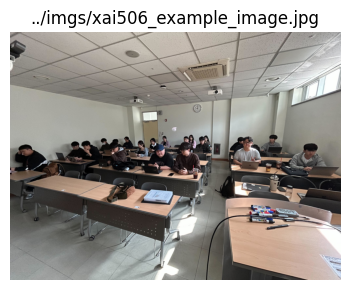

In [5]:
# 이미지 경로 (노트북 기준 상대 경로)
impath = "../imgs/xai506_example_image.jpg"
img_pil = Image.open(impath).convert("RGB")
img_np = np.array(img_pil)
h, w = img_np.shape[:2]
print("shape:", img_np.shape, "dtype:", img_np.dtype)

fig, ax = plt.subplots(figsize=(4, 4 * h / max(1, w)))
ax.imshow(img_np)
ax.set_title(impath)
ax.axis("off")
plt.tight_layout()
plt.show()

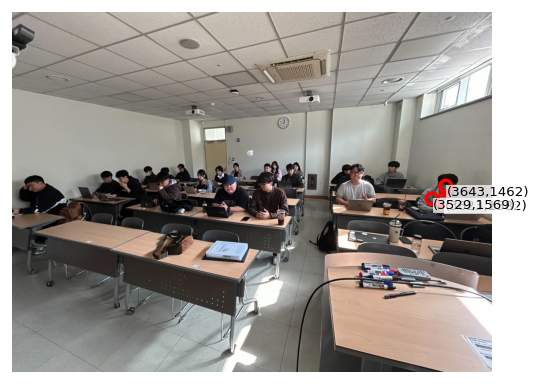

pos: [[3623, 1582], [3643, 1462], [3529, 1569]]
neg: []


In [6]:
# Jupyter에서 창이 안 뜨면 커널에서 한 번 `%gui qt5` 실행 후 다시 시도하세요.
import sys
from PyQt5.QtWidgets import QApplication
_qt_app = QApplication.instance()
if _qt_app is None:
    _qt_app = QApplication(sys.argv)
try:
    _qt_app.setStyle("Fusion")
except Exception:
    pass

# PyQt5: 왼쪽 클릭=positive, 오른쪽=negative, Enter/Esc=완료, Backspace=마지막 점 취소
pos, neg = pick_pos_neg_points_qt(
    img_np,
    y_offset=0.1,
    window_width=0.4,
    window_height=0.4,
    fit_to_window=True,
    allow_upscale=True,
    max_display_width=None,
    verbose=False,
    show_image=True,
    fig_w=4,
)
print("pos:", pos)
print("neg:", neg)


**헤드리스 / Qt 불가 시:** `pos`, `neg`를 픽셀 좌표 `[[x, y], ...]` 로 직접 지정한 뒤 추론 셀을 실행하세요.

```python
pos = [[w // 2, h // 2]]
neg = [[10, 10]]
```


In [7]:
mask, mask_ = sam2_predict_masks(
    model,
    processor,
    device,
    img_pil,
    pos,
    neg,
    fill_holes=True,
    keep_largest=True,
)
print("mask:", mask.shape, mask.dtype, "fg pixels:", int(mask.sum()))

mask: (3024, 4032) bool fg pixels: 88609


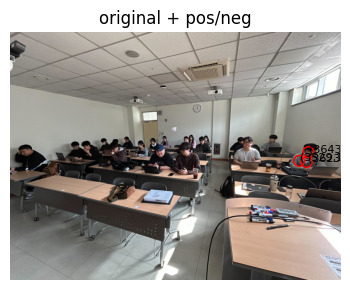

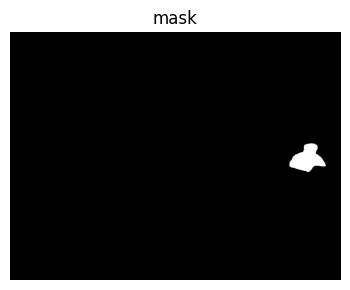

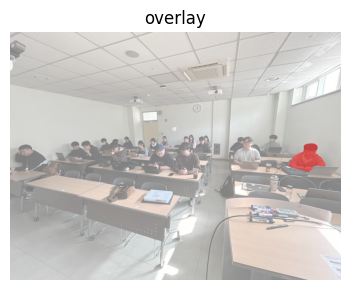

In [8]:
plot_segmask(img_np, mask=mask, pos=pos, neg=neg, alpha=0.5, bright=0.5, fig_w=4)

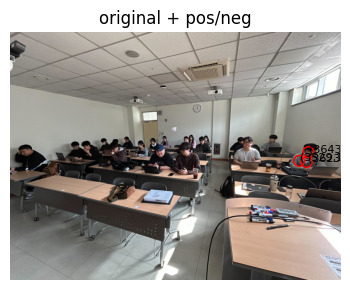

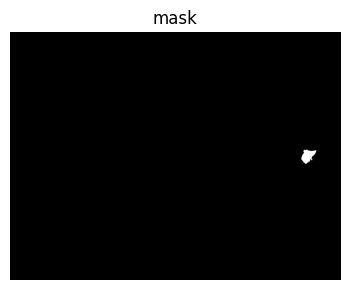

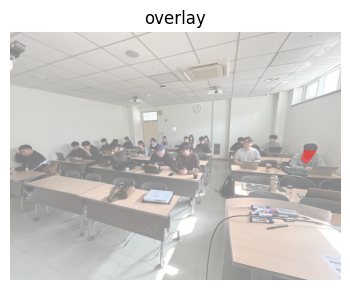

In [9]:
# 후보 중 면적이 가장 작은 마스크 (원본 노트북의 mask_ 시각화에 대응)
plot_segmask(img_np, mask=mask_, pos=pos, neg=neg, alpha=0.5, bright=0.5, fig_w=4)